In [1]:
import sys
sys.path.append('../')

import numpy as np
import scipy.sparse as ssp
import matplotlib.pyplot as plt
import qutip as qt
import scqubits as scq
from sympy import symbols
import utils_2Q_gate_zp as ut
ut.set_fig_font() ### Set various sizes in plotting
import scipy as sp
import pandas as pd
from joblib import Parallel, delayed
import itertools
# Reset to the default Matplotlib color cycle
plt.rcParams['axes.prop_cycle'] = plt.rcParamsDefault['axes.prop_cycle']

# CNOT

In [14]:
truc = [60, 80, 100, 120, 140, 160, 180, 200, 220, 240, 500, 1000]
tg_vec = [40, 100, 160, 220, 280, 340]
f_ideal = np.array([
[-0.2408710267680025, -0.4033348580726855, -0.40877583348473273, -0.3188491438883187, -0.44689304288684145, -0.5850322582290323] ,
[-0.4109050803561779, -1.042291504026245, -1.6760589050926824, -1.9616646479854347, -2.2103037534826098, -2.396020228617471] ,
[-0.4286802112359631, -1.007827159199315, -1.6532847073182517, -1.9497673310419474, -2.2043838383761227, -2.395230164275512] ,
[-0.5052176329025952, -1.0178304927695925, -1.7145810969260442, -2.054214826800078, -2.315393405379015, -2.511890997635173] ,
[-0.5109908026173182, -1.0226785864814987, -1.7140804212853773, -2.047481576473105, -2.304953696188171, -2.499687483051231] ,
[-0.5170850146855277, -1.028871046946848, -1.702451764755672, -2.027041783937793, -2.282582358640897, -2.4756670879350784] ,
[-0.5124550141405817, -1.0274695106624743, -1.696583309637881, -2.0195841179199103, -2.2739421896344654, -2.4665499946293363] ,
[-0.42841089097330964, -0.9954891640066846, -1.6912374526769474, -2.159770735378756, -2.4186284715071307, -2.6082271530413554] ,
[-0.40474120682724435, -0.9966463629456127, -1.9325894456297759, -2.85829946032206, -3.286007836646338, -3.546363024028559] ,
[-0.40321104953155307, -0.9937389354394224, -1.9695521633895876, -2.8676054858368687, -3.3008107079762885, -3.5627574087617337] ,
[-0.42068515335936574, -0.9970894290260882, -1.9777551750892823, -2.8724656067799095, -3.3025364662157197, -3.5632860625508083] ,
[-0.4176662559430338, -0.994703520688895, -1.9793738955300706, -2.8684693474289134, -3.301410633067448, -3.562286362325203] ,
])

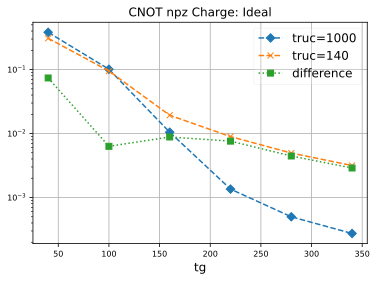

In [24]:
truc_1 = 1000
truc_2 = 140
truc_1_idx = truc.index(truc_1)
truc_2_idx = truc.index(truc_2)
f1 = 10**f_ideal[truc_1_idx]
f2 = 10**f_ideal[truc_2_idx]
f_diff = np.abs(f1 - f2)

fig, ax = plt.subplots(figsize=(6,4))
ax.plot(tg_vec, f1, 'D--', label=f'truc={truc_1}')
ax.plot(tg_vec, f2, 'x--', label=f'truc={truc_2}')
ax.plot(tg_vec, f_diff, 's:',  label=r'difference')
plt.yscale('log')
plt.xlabel('tg', fontsize=12)
plt.title(rf'CNOT npz Charge: Ideal', fontsize=12)
plt.grid()
legend = plt.legend(loc='best', fontsize=12)
legend.get_frame().set_alpha(0.2)  # 0.5 makes the legend 50% transparent

In [18]:
np.arange(0, 179, step=6)

array([  0,   6,  12,  18,  24,  30,  36,  42,  48,  54,  60,  66,  72,
        78,  84,  90,  96, 102, 108, 114, 120, 126, 132, 138, 144, 150,
       156, 162, 168, 174])

In [20]:
np.arange(0, 179, step=30)

array([  0,  30,  60,  90, 120, 150])

# CZ

In [19]:
truc_vec = np.arange(200, 401, 10)
tg_vec = [20, 56, 92, 128, 164]
f_ideal = np.array([
[-0.5786985610959464, -1.0030817813804533, -2.5692255922883596, -2.9972609588853993, -3.72329256355352] ,
[-0.5774820530077807, -1.0039878127709718, -2.562387575054795, -2.9973950539377126, -3.723171862451506] ,
[-0.5804982189787136, -1.0026870277159374, -2.5548838601627364, -2.9972598724566324, -3.7231324231265996] ,
[-0.5777530884901941, -1.0000803853948486, -2.5450884133462113, -2.9973087172488566, -3.7229433394918674] ,
[-0.5782317612983469, -1.000202571445917, -2.5409220038626015, -2.9973261924692576, -3.722953440001135] ,
[-0.5798280965501301, -1.0000401303008586, -2.5410087133214434, -2.997215718032983, -3.722879778221148] ,
[-0.5968041506331252, -1.0059577945112204, -2.6920760638204593, -2.9963118902108605, -3.7192548597533936] ,
[-0.6122603880458696, -1.0087942247467039, -2.872196434660553, -2.9957843996152036, -3.719005907414838] ,
[-0.6123457047791835, -1.0087070888663099, -2.8692635140836424, -2.99568710613785, -3.71894013330415] ,
[-0.6132268604218765, -1.0086887488073486, -2.884148647343154, -2.995560599773691, -3.718895138894725] ,
[-0.6136820301045681, -1.0086795398597457, -2.881533989585849, -2.9955196949864518, -3.718779708953811] ,
[-0.6142588336016125, -1.00868697101155, -2.8900932365649528, -2.995478864173952, -3.7187870956396223] ,
[-0.6141811462029818, -1.0086738845366257, -2.890227245991135, -2.9954107975025535, -3.7187971195408673] ,
[-0.6140981234749182, -1.0086005788909351, -2.8889576995370967, -2.9952741867271953, -3.7186951840580975] ,
[-0.6140340218839915, -1.0084982275594467, -2.8854923491076043, -2.995114043202525, -3.718792773532098] ,
[-0.6145656387390431, -1.0084979629314919, -2.882273255880006, -2.995071565279411, -3.7187765486048203] ,
[-0.6146339333551152, -1.0084786170753528, -2.8819415642705755, -2.9949768615084484, -3.718709290473119] ,
[-0.61472748188849, -1.0084066977104582, -2.8777612115829636, -2.9949296090616526, -3.718691900065843] ,
[-0.6148573689880967, -1.0084162965913872, -2.877673445471636, -2.9949033303593375, -3.718732692926493] ,
[-0.6154973457350476, -1.0082907735828353, -2.875955156445109, -2.994726468259497, -3.7188207660462482] ,
[-0.6154480637200438, -1.0082457440403438, -2.875450993459644, -2.9942577899197445, -3.718429321236124] ,
])

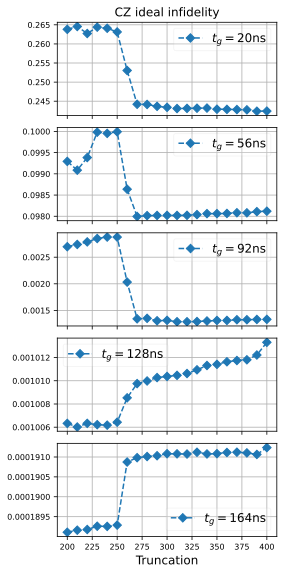

: 

In [ ]:
cut = 21

fig, ax = plt.subplots(5, 1, figsize=(4, 8), sharex=True)
for i, tg_i in enumerate(tg_vec):
    ax[i].plot(truc_vec[:cut], 10**f_ideal[:cut,i], 'D--', label=fr'$t_g = {tg_vec[i]:.0f}$ns')
    ax[i].grid()
    legend = ax[i].legend(loc="best", fontsize=12)
    legend.get_frame().set_alpha(0.2)
    # ax[i].set_ylabel(fr'$t_g = {params[:,0][i]:.0f}$ns')
ax[4].set_xlabel('Truncation', fontsize=12)
ax[0].set_title(fr'CZ ideal infidelity', fontsize=12)
plt.tight_layout()

## CZ Noise

In [ ]:
# CZ

tg_vec = np.array([0, 45, 90, 135, 179]) + 20

f_ideal_55 = np.array([
-0.20377267, -0.98452684, -2.28869148, -3.15605242 ,
-3.91162699 ,
])
f_170us_55 = np.array([
-0.20377304, -0.98426348, -2.27820753, -3.07275232 ,
-3.51700110 ,
])
f_3us_55 = np.array([
-0.20410531, -0.97240755, -2.00086711, -2.18801348 ,
-2.13046380 ,
])

f_ideal_60 = np.array([
-0.36874608, -1.11939866, -2.35454828, -3.38951000 ,-4.28424183
])
f_170us_60 = np.array([
-0.36874161, -1.11899328, -2.34193337, -3.25271458 ,-3.62631826
])

f_ideal_70 = np.array([
[-0.3904669902251444] ,[-1.132004234779337] ,[-2.348373491119492] ,[-3.3949151884312543] ,[-4.294159392862067] ,
])

f_170us_70 = np.array([
[-0.3904577073654728] ,[-1.13157491401442] ,[-2.3357348054961204] ,[-3.2528919843582806] ,[-3.619127324102469] ,
])

f_ideal_90 = np.array([
[-0.3145254000949166] ,[-1.0903140492904109] ,[-2.36183883408944] ,[-3.378487250079478] ,[-4.291935825523835] ,
])

f_170us_90 = np.array([
[-0.3145141047283958] ,[-1.0899135333783507] ,[-2.3482242592821008] ,[-3.2392878787820742] ,[-3.6163740934017707] ,
])

f_ideal_100 = np.array([
-0.53616240 ,-1.11219009 ,-2.34602104 ,-3.38750168 ,-4.29421009 ,
])
f_170us_100 = np.array([
-0.53608090 ,-1.11175930 ,-2.33254374 ,-3.24393142 ,-3.61343377 ,
])

f_ideal_150 = np.array([
-0.53811773, -1.11482390, -2.34622520, -3.38920011 ,
-4.29595245 ,
])
f_170us_150 = np.array([
-0.53803271, -1.11433664, -2.33174151, -3.23833190 ,
-3.60122762 ,
])

tg200 = [20, 92]
f_ideal_200 = np.array([
-0.57869856 ,
-2.56922559 ,
])
f_170us_200 = np.array([
-0.57861055 ,
-2.54349802 ,
])

tg_vec = np.array([0, 45, 90, 135, 179]) + 20
f_ideal_900 = np.array([

])

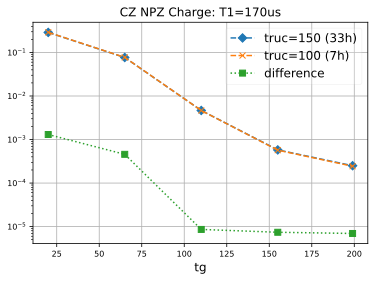

In [3]:
fig, ax = plt.subplots(figsize=(6,4))
ax.plot(tg_vec, 10**f_170us_150, 'D--', label=f'truc=150 (33h)')
ax.plot(tg_vec, 10**f_170us_100, 'x--', label=f'truc=100 (7h)')
ax.plot(tg_vec, np.abs(10**f_170us_150 - 10**f_170us_100), 's:',  label=r'difference')
# ax.plot(tg_vec, 10**f_170us_55, '.--', label=f'truc=55 (2h)')
plt.yscale('log')
plt.xlabel('tg', fontsize=12)
plt.title(rf'CZ NPZ Charge: T1=170us', fontsize=12)
plt.grid()
legend = plt.legend(loc='best', fontsize=12)
legend.get_frame().set_alpha(0.2)  # 0.5 makes the legend 50% transparent

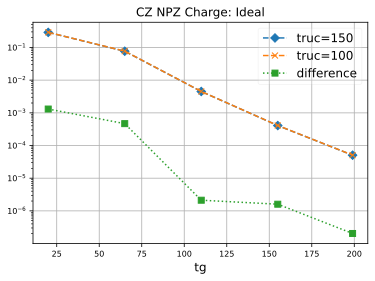

In [11]:
fig, ax = plt.subplots(figsize=(6,4))
ax.plot(tg_vec, 10**f_ideal_150, 'D--', label=f'truc=150')
ax.plot(tg_vec, 10**f_ideal_100, 'x--', label=f'truc=100')
ax.plot(tg_vec, np.abs(10**f_ideal_150 - 10**f_ideal_100), 's:',  label=r'difference')
# ax.plot(tg_vec, 10**f_170us_55, '.--', label=f'truc=55 (2h)')
plt.yscale('log')
plt.xlabel('tg', fontsize=12)
plt.title(rf'CZ NPZ Charge: Ideal', fontsize=12)
plt.grid()
legend = plt.legend(loc='best', fontsize=12)
legend.get_frame().set_alpha(0.2)  # 0.5 makes the legend 50% transparent

In [12]:
tg_vec = [199]
truc_199 = np.array([55, 60, 70, 80, 90, 100, 110, 120, 130, 140, 150])

f_ideal_199 = np.array([ [-3.91162699],
    [-4.28424183],    [-4.29415939],    [-4.29616918],    [-4.29193583],
    [-4.29421009],    [-4.29659940],    [-4.29658420],    [-4.29625560],
    [-4.29586239],  [-4.29595245],
])

f_170us_199 = np.array([ [-3.51700110],
    [-3.62631826],    [-3.61912732],    [-3.62238024],    [-3.61637409],
    [-3.61343377],    [-3.61058094],    [-3.60923093],    [-3.60629153],
    [-3.60440511],  [-3.60122762],
])

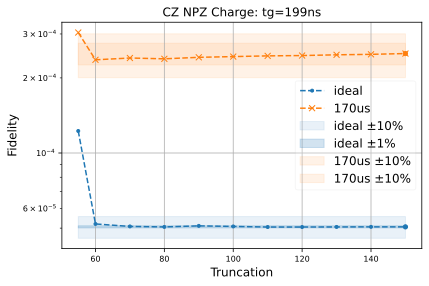

In [16]:
fig, ax = plt.subplots(figsize=(6, 4))

y_ideal = 10**f_ideal_199
y_noise = 10**f_170us_199

ax.plot(truc_199, y_ideal, '.--', color='C0', label='ideal')
ax.plot(truc_199, y_noise, 'x--', color='C1', label='170us')

# Reference index at largest truc
i_ref = np.argmax(truc_199)
x_ref = truc_199[i_ref]
ref_ideal = y_ideal[i_ref]
ref_noise = y_noise[i_ref]

x_min, x_max = np.min(truc_199), np.max(truc_199)

# ideal bands
ax.fill_between([x_min, x_max], ref_ideal*0.90, ref_ideal*1.10,
                color='C0', alpha=0.10, label='ideal ±10%')
ax.fill_between([x_min, x_max], ref_ideal*0.99, ref_ideal*1.01,
                color='C0', alpha=0.20, label='ideal ±1%')

# 170us bands
ax.fill_between([x_min, x_max], ref_noise*0.80, ref_noise*1.20,
                color='C1', alpha=0.10, label='170us ±10%')
ax.fill_between([x_min, x_max], ref_noise*0.90, ref_noise*1.10,
                color='C1', alpha=0.10, label='170us ±10%')
# ax.fill_between([x_min, x_max], ref_noise*0.99, ref_noise*1.01,
#                 color='C1', alpha=0.20, label='170us ±1%')

# mark reference points
ax.scatter([x_ref], [ref_ideal], color='C0', s=18, zorder=5)
ax.scatter([x_ref], [ref_noise], color='C1', s=18, zorder=5)

ax.set_yscale('log')
ax.set_xlabel('Truncation', fontsize=12)
ax.set_ylabel('Fidelity', fontsize=12)
ax.legend(fontsize=7, loc='best', ncol=2)
plt.title(rf'CZ NPZ Charge: tg=199ns', fontsize=12)
plt.grid()
legend = plt.legend(loc='best', fontsize=12)
legend.get_frame().set_alpha(0.2)  # 0.5 makes the legend 50% transparent
plt.tight_layout()

In [17]:
truc_92 = np.array([60, 70, 80, 90, 100, 110, 120, 130])

f_ideal_92 = np.array([
    -3.06910213,    -3.05960229,    -3.05249609,    -2.98349280,
    -2.92870236,    -2.93471718,    -2.94068041,    -2.94097401,
])

f_noise_92 = np.array([
    -3.00592657,    -2.99666301,    -2.98871430,    -2.92759864,
    -2.87758209,    -2.88193753,    -2.88649123,    -2.88591054,
])

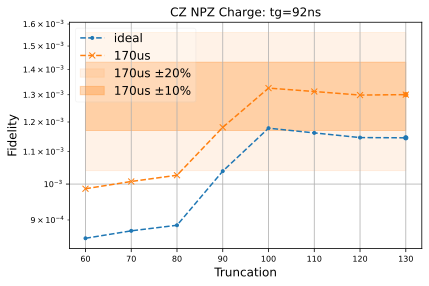

In [20]:
fig, ax = plt.subplots(figsize=(6, 4))

y_ideal = 10**f_ideal_92
y_noise = 10**f_noise_92

ax.plot(truc_92, y_ideal, '.--', color='C0', label='ideal')
ax.plot(truc_92, y_noise, 'x--', color='C1', label='170us')

# Reference index at largest truc
i_ref = np.argmax(truc_92)
x_ref = truc_92[i_ref]
ref_ideal = y_ideal[i_ref]
ref_noise = y_noise[i_ref]

x_min, x_max = np.min(truc_92), np.max(truc_92)

# ideal bands
# ax.fill_between([x_min, x_max], ref_ideal*0.90, ref_ideal*1.10,
#                 color='C0', alpha=0.10, label='ideal ±10%')
# ax.fill_between([x_min, x_max], ref_ideal*0.99, ref_ideal*1.01,
#                 color='C0', alpha=0.20, label='ideal ±1%')

# 170us bands
ax.fill_between([x_min, x_max], ref_noise*0.80, ref_noise*1.20,
                color='C1', alpha=0.10, label='170us ±20%')
ax.fill_between([x_min, x_max], ref_noise*0.90, ref_noise*1.10,
                color='C1', alpha=0.30, label='170us ±10%')
# ax.fill_between([x_min, x_max], ref_noise*0.99, ref_noise*1.01,
#                 color='C1', alpha=0.20, label='170us ±1%')

# mark reference points
ax.scatter([x_ref], [ref_ideal], color='C0', s=18, zorder=5)
ax.scatter([x_ref], [ref_noise], color='C1', s=18, zorder=5)

ax.set_yscale('log')
ax.set_xlabel('Truncation', fontsize=12)
ax.set_ylabel('Fidelity', fontsize=12)
ax.legend(fontsize=7, loc='best', ncol=2)
plt.title(rf'CZ NPZ Charge: tg=92ns', fontsize=12)
plt.grid()
legend = plt.legend(loc='upper left', fontsize=12)
legend.get_frame().set_alpha(0.2)  # 0.5 makes the legend 50% transparent
plt.tight_layout()

## Test run_cz_fidelity.py

In [3]:
import ham_data as hd

n_truc_list = [55] # [200, 250, 1000] # np.arange(100, 1001, 50) #
cz_run = True # True  # whether to use CZ gate or CNOT gate

# 300_2000_True; 300_2000_False
# truc_one_qubit, truc_full, charge_pick = 300, 1000, True 

# 'cz_short_500_detune0', 'cz_short_500_detune1', 'hand_pick',
use_truc_model, truc_model_name = True, 'cz_short_500_detune1'

# below sets whether to calculate noisy fidelity, they should not be true at the same time to avoid error
calculate_ideal, calculate_noise = True, True # True, False #     
apply_decay, apply_dephase = True, True # True, False # Whether to apply decay and dephasing
decay_enlarge = 1 # change this to test decay
filter_ratio = 0.3

t1_tphi_other = 3 # μs
tg_list = [0] # [  0,  45,  90, 135, 179] #np.arange(180)[0::43] # [0::6] # [  0,  45,  90, 135, 179] # np.arange(180) #[0::3]
# np.arange(181)[0::6] # [2, 9, 16, 23, 30] # Select the first row for testing
max_step_ideal, max_step_noisy = 1e-3, 1e-3 # Set max_step to 0 for parallel execution
num_cpus, n_job = 16, len(tg_list) # Number of CPUs and jobs for parallel processing

# folder_load = '../../data/_truc_3000'
folder_load = '../data/Two_qubit_data_Sorted_Truc'

data = hd.load_two_qubit_data(folder_load, return_full=False)
[hspace_full, eket_tot, eval_tot, n_theta0, n_theta1, n_theta0_dress, n_theta1_dress, 
hspace_0, hspace_1, hspace_n_theta1, hspace_n_theta2, logi_state] = data


In [4]:

dim_0 = len(hspace_0)
dim_1 = len(hspace_1) 

# Load pulse parameters from CSV
folder = 'data/npz/cz_pulse_neighbor.txt'
params = ut.load_drive_params_2q(cz_run, folder=folder)[tg_list, ]  # [1::4,] 
    
option_ideal, option_noisy = ut.get_qutip_options(max_step_ideal, max_step_noisy) 

if cz_run: # CZ
    drive_term = n_theta1_dress
    W_20_50 = ( eval_tot[hspace_full.index('5-0')] - 
                eval_tot[hspace_full.index('2-0')] )
    print(f'Using CZ gate with W_20_50 = {W_20_50}')
else: # CNOT     
    drive_term = n_theta0_dress
    mid_state = '8-2'
    idx_0 = hspace_full.index('0-2')
    idx_1 = hspace_full.index('2-2')
    idx_2 = hspace_full.index(mid_state)
    W_0_2 = eval_tot[idx_2] - eval_tot[idx_0]
    W_1_2 = eval_tot[idx_2] - eval_tot[idx_1]
    print(f'Using CNOT gate with W_0_2 = {W_0_2}, W_1_2 = {W_1_2}')
    print('\nmid_state = ', mid_state)
print(f"calculate_ideal = {calculate_ideal}, calculate_noise = {calculate_noise}")
print(f'apply_decay={apply_decay}, apply_dephase={apply_dephase}')
print(f'filter_ratio = {filter_ratio}, decay_enlarge = {decay_enlarge}')     
print(f'use_truc_model = {use_truc_model}, truc_model_name = {truc_model_name}')
print(f"t1_tphi_other = {t1_tphi_other}")
# print(f"truc_one_qubit = {truc_one_qubit}, truc_full={truc_full}, charge_pick={charge_pick}")
print('num_cpus=', num_cpus, ', n_job=', n_job)
ut.print_fidelity(f'params', params.tolist(), num_each_row=1)    


Using CZ gate with W_20_50 = 15.991864479678007
calculate_ideal = True, calculate_noise = True
apply_decay=True, apply_dephase=True
filter_ratio = 0.3, decay_enlarge = 1
use_truc_model = True, truc_model_name = cz_short_500_detune1
t1_tphi_other = 3
num_cpus= 16 , n_job= 1

params = np.array([
[20.0396, 0.042986, 0.024999] ,
])


In [ ]:
[n_theta0_test, n_theta1_test, gamma_dephase_02_q0, gamma_dephase_02_q1
] = ut.load_noise_data_2q(t1_tphi_other) 

In [ ]:
qt.Qobj(n_theta0_test[:10,:10]).tidyup(atol=1e-3)

Quantum object: dims = [[10], [10]], shape = (10, 10), type = oper, isherm = True
Qobj data =
[[ 0.         -1.35218494  0.          0.          0.          0.00440778
   0.          0.         -0.04375543  0.        ]
 [-1.35218494  0.         -0.01039451  0.          1.85992081  0.
   0.          0.          0.          0.05480165]
 [ 0.         -0.01039451  0.          0.          0.         -1.33423477
   0.          0.         -0.06549022  0.        ]
 [ 0.          0.          0.          0.          0.          0.
   1.33640594  0.          0.          0.        ]
 [ 0.          1.85992081  0.          0.          0.         -0.14287071
   0.          0.          2.18191516  0.        ]
 [ 0.00440778  0.         -1.33423477  0.         -0.14287071  0.
   0.          0.          0.          1.71935551]
 [ 0.          0.          0.          1.33640594  0.          0.
   0.         -0.04130832  0.          0.        ]
 [ 0.          0.          0.          0.          0.          

In [ ]:
qt.Qobj(n_theta0[:10,:10]).tidyup(atol=1e-3) / 6.28

Quantum object: dims = [[10], [10]], shape = (10, 10), type = oper, isherm = True
Qobj data =
[[ 0.         -1.3530398   0.          0.          0.         -0.00436923
   0.          0.         -0.04379472  0.        ]
 [-1.3530398   0.          0.01023919  0.         -1.86108854  0.
   0.          0.          0.         -0.05442315]
 [ 0.          0.01023919  0.          0.          0.         -1.33542546
   0.          0.          0.0639596   0.        ]
 [ 0.          0.          0.          0.          0.          0.
  -1.33750755  0.          0.          0.        ]
 [ 0.         -1.86108854  0.          0.          0.         -0.14050028
   0.          0.         -2.18330122  0.        ]
 [-0.00436923  0.         -1.33542546  0.         -0.14050028  0.
   0.          0.          0.          1.7248294 ]
 [ 0.          0.          0.         -1.33750755  0.          0.
   0.          0.04131419  0.          0.        ]
 [ 0.          0.          0.          0.          0.          

: 

In [ ]:

f_list = []
for n_truc in n_truc_list:
    if use_truc_model:
        if cz_run:
            hspace_select = hspace_full[:n_truc]
            # hspace_select = ut.truc_model[truc_model_name][:n_truc]
        else:
            hspace_select = ut.truc_model[truc_model_name][:n_truc]
    else:
        hspace_select = hspace_full[:n_truc]


    index_select = [hspace_full.index(i) for i in hspace_select]
    H_drive_select, eket_truc = ut.build_hamiltonian_2q(cz_run, index_select, eval_tot, 
                                                        eket_tot, drive_term)
    logi_idx_select = [hspace_select.index(i) for i in logi_state]

    ut.print_fidelity(f'hspace_select (len={len(hspace_select)})', 
                    hspace_select, num_each_row=10)

    ut.print_fidelity(f'index_select (len={n_truc})', index_select, num_each_row=10)

    if calculate_ideal: # ideal fidelity
        c_op_list = []
        if cz_run:
            arg_select = [H_drive_select, W_20_50, num_cpus, c_op_list, 
                            logi_idx_select, option_ideal, option_noisy]
            f_ideal = Parallel(n_jobs=n_job)(delayed(ut.cz_fidelity_log_noise)
                                                (args_indep, *arg_select)
                                            for args_indep in params)
        else:
            arg_select = [H_drive_select, W_0_2, W_1_2, num_cpus, c_op_list, 
                            logi_idx_select, mid_state, option_ideal, option_noisy]
            f_ideal = Parallel(n_jobs=n_job)(delayed(ut.cnot_fidelity_log_noise)
                                                (args_indep, *arg_select)
                                            for args_indep in params)        
        ut.print_fidelity(f'f_ideal_{n_truc}', f_ideal, num_digits=8)
        ut.print_time()      

    if calculate_noise: # Noisey fidelity       
        ###################################
        data = np.load('../data/flux_derivative_truc500/gamma_phi_2Q_truc500.npz')
        gamma_dephase_02_q0 = np.abs(data['q0'] /t1_tphi_other)
        gamma_dephase_02_q1 = np.abs(data['q1'] /t1_tphi_other)

        n_theta0 = n_theta0_dress.copy()#[:n_truc,:n_truc]
        n_theta1 = n_theta1_dress.copy()#[:n_truc,:n_truc]

        Gamma = 1 / 1e3 / t1_tphi_other
        Gamma_decay_q0 = Gamma / (n_theta0[4,8]**2)
        Gamma_decay_q1 = Gamma / (n_theta1[4,8]**2)
        transition_a, n_theta0_trunc = ut.get_transitions_for_collapse(hspace_0, n_theta0, 
                                                                    filter_ratio=filter_ratio)
        transition_b, n_theta1_trunc = ut.get_transitions_for_collapse(hspace_1, n_theta1, 
                                                                    filter_ratio=filter_ratio)
        # Construct collapse operators
        c_op_list = ut.construct_c_ops_2q(dim_0, dim_1, n_theta0_trunc, n_theta1_trunc, 
                                            gamma_dephase_02_q0, gamma_dephase_02_q1, eket_truc, 
                                            Gamma_decay_q0, Gamma_decay_q1, 
                                            transition_a, transition_b, 
                                            apply_decay, apply_dephase, decay_enlarge )     
        print(f'np.shape(c_op_list) = {np.shape(c_op_list)}')     

        arg_select = [H_drive_select, W_20_50, num_cpus, c_op_list, logi_idx_select, 
                    option_ideal, option_noisy]
        
#         f_noise = Parallel(n_jobs=n_job)(delayed(ut.cz_fidelity_log_noise)
#                                             (args_indep, *arg_select)
#                                         for args_indep in params)
#         ut.print_fidelity(f'f_{t1_tphi_other}us_{n_truc}', f_noise, num_digits=8)
#         ut.print_time()
#     f_list.append(f_ideal if calculate_ideal else f_noise)
# print(f'n_truc_list = {np.array(n_truc_list).tolist()}')     
# ut.print_fidelity(f'fidelity_list', f_list, num_each_row=1, num_digits=8)          

In [ ]:
qt.Qobj(n_theta0[:10,:10]).tidyup(atol=1e-3)


Quantum object: dims = [[10], [10]], shape = (10, 10), type = oper, isherm = True
Qobj data =
[[ 0.00000000e+00  2.72445902e+00 -8.05171277e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  1.14495843e-02]
 [ 2.72445902e+00  0.00000000e+00  0.00000000e+00 -5.76168690e-03
  -2.16143804e-02  2.37063190e+00  8.00106473e+00 -3.05571693e+00
   0.00000000e+00  0.00000000e+00]
 [-8.05171277e+00  0.00000000e+00  0.00000000e+00 -1.59927770e-03
   6.04525067e-02  2.73411934e-02 -6.13982006e+00 -9.60637166e+00
   0.00000000e+00  0.00000000e+00]
 [ 0.00000000e+00 -5.76168690e-03 -1.59927770e-03  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   1.96871660e+00  0.00000000e+00]
 [ 0.00000000e+00 -2.16143804e-02  6.04525067e-02  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  3.60192582e+00]
 [ 0.00000000e+00  2.37063190e+00  2.73411934e-02  0.00000000e+00
   0.

In [ ]:
qt.Qobj(n_theta0_dress[:10,:10]).tidyup(atol=1e-3)


Quantum object: dims = [[10], [10]], shape = (10, 10), type = oper, isherm = True
Qobj data =
[[ 0.00000000e+00  2.72445902e+00 -8.05171277e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  1.14495843e-02]
 [ 2.72445902e+00  0.00000000e+00  0.00000000e+00 -5.76168690e-03
  -2.16143804e-02  2.37063190e+00  8.00106473e+00 -3.05571693e+00
   0.00000000e+00  0.00000000e+00]
 [-8.05171277e+00  0.00000000e+00  0.00000000e+00 -1.59927770e-03
   6.04525067e-02  2.73411934e-02 -6.13982006e+00 -9.60637166e+00
   0.00000000e+00  0.00000000e+00]
 [ 0.00000000e+00 -5.76168690e-03 -1.59927770e-03  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   1.96871660e+00  0.00000000e+00]
 [ 0.00000000e+00 -2.16143804e-02  6.04525067e-02  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  3.60192582e+00]
 [ 0.00000000e+00  2.37063190e+00  2.73411934e-02  0.00000000e+00
   0.

In [ ]:
print(hspace_0)

[0, 1, 2, 4, 5, 8, 9, 12, 13, 15, 18, 20, 22, 24, 25, 26, 28, 30, 33, 34, 35, 37, 39, 41, 44, 45, 46, 50, 51, 54, 56, 58, 59, 60, 64, 65, 66, 69, 70, 74, 75, 77, 79, 81, 84, 85, 86, 89, 90, 92, 93, 98, 99, 100, 101, 102, 105, 106, 109, 110, 111, 114, 116, 121, 123, 125, 127, 128, 129, 131, 132, 135, 137, 138, 140, 141, 144, 146, 147, 149, 151, 154, 157, 159, 161, 162, 165, 167, 169, 170, 173, 174, 175, 177, 179, 180, 183, 185, 188, 189, 194, 195, 198, 199, 200, 202, 204, 206, 208, 209, 210, 213, 214, 216, 217, 222, 223, 224, 225, 228, 229, 234, 235, 238, 241, 244, 247, 248, 249, 250, 251, 252, 254, 255, 260, 261, 262, 263, 264, 265, 269, 270, 271, 275, 277, 281, 282, 285, 288, 289, 293, 294, 295, 299]
